In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data = pd.read_excel('cleaned_data.xlsx')

In [8]:
print(data.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  CorrectTotalPrice  
0     SAVE10      Instagram     2853.10            2853.10  
1     SAVE10      

In [9]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   OrderID            1200 non-null   str           
 1   Date               1200 non-null   datetime64[us]
 2   CustomerID         1200 non-null   str           
 3   Product            1200 non-null   str           
 4   Quantity           1200 non-null   int64         
 5   UnitPrice          1200 non-null   float64       
 6   ShippingAddress    1200 non-null   str           
 7   PaymentMethod      1200 non-null   str           
 8   OrderStatus        1200 non-null   str           
 9   TrackingNumber     1200 non-null   str           
 10  ItemsInCart        1200 non-null   int64         
 11  CouponCode         1200 non-null   str           
 12  ReferralSource     1200 non-null   str           
 13  TotalPrice         1200 non-null   float64       
 14  CorrectTotalPrice  

In [10]:
print(data.describe())

                      Date     Quantity    UnitPrice  ItemsInCart  \
count                 1200  1200.000000  1200.000000  1200.000000   
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000   
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000   
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000   
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000   
std                    NaN     1.407557   197.177146     2.281983   

        TotalPrice  CorrectTotalPrice  
count  1200.000000        1200.000000  
mean   1053.968300        1053.968300  
min      11.390000          11.390000  
25%     410.520000         410.520000  
50%     823.615000         823.615000  
75%    1578.475000        1578.475000  
max    3456.400000        3456.400000  
std     819.856558         819.856558  


In [11]:
product_sales = data.groupby('Product')['TotalPrice'].sum()

print(product_sales)

Product
Chair      195620.11
Desk       167459.93
Laptop     192126.56
Monitor    175651.41
Phone      151722.39
Printer    195612.61
Tablet     186568.95
Name: TotalPrice, dtype: float64


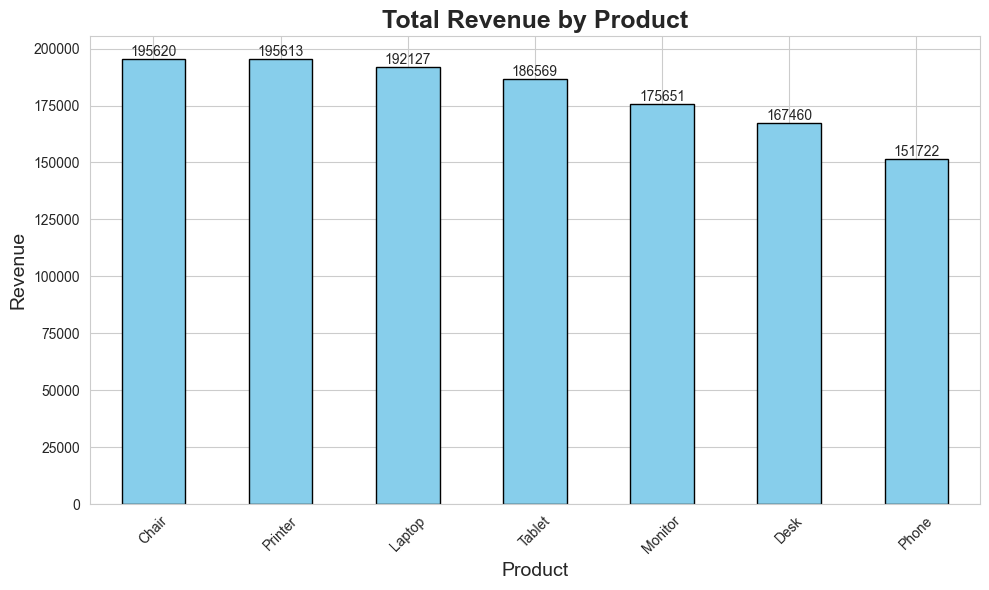

In [23]:

sns.set_style("whitegrid")


plt.figure(figsize=(10,6))


product_sales.sort_values(ascending=False).plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)


plt.title(
    'Total Revenue by Product',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Product',
    fontsize=14
)

plt.ylabel(
    'Revenue',
    fontsize=14
)


plt.xticks(rotation=45)


for index, value in enumerate(product_sales.sort_values(ascending=False)):
    plt.text(
        index,
        value,
        f'{value:.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )


plt.tight_layout()

plt.show()

In [13]:
print(data['PaymentMethod'].value_counts())

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


In [14]:
print(data['OrderStatus'].value_counts())

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


In [15]:
correlation = data[['Quantity', 'UnitPrice', 'TotalPrice']].corr()

print(correlation)

            Quantity  UnitPrice  TotalPrice
Quantity    1.000000   0.014553    0.615251
UnitPrice   0.014553   1.000000    0.717081
TotalPrice  0.615251   0.717081    1.000000


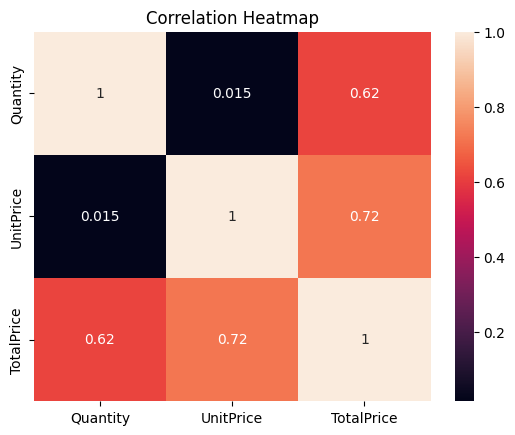

In [16]:
sns.heatmap(correlation, annot=True)

plt.title('Correlation Heatmap')

plt.show()

In [17]:
Q1 = data['TotalPrice'].quantile(0.25)
Q3 = data['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[
    (data['TotalPrice'] < lower) |
    (data['TotalPrice'] > upper)
]

print(outliers)

        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
107   ORD200107 2023-03-27     C16775  Printer         5     670.75   
326   ORD200326 2024-07-01     C65986   Laptop         5     670.48   
328   ORD200328 2023-02-28     C18404   Tablet         5     674.04   
469   ORD200469 2023-11-26     C13877    Chair         5     676.98   
632   ORD200632 2023-05-02     C67260   Laptop         5     678.16   
789   ORD200789 2023-08-17     C57276   Tablet         5     691.28   
1065  ORD201065 2023-10-30     C47778  Printer         5     666.80   
1122  ORD201122 2023-06-07     C38840  Monitor         5     678.19   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
107      848 Main St     Gift Card     Shipped    TRK34392124            8   
326      273 Main St     Gift Card    Returned    TRK98353867            5   
328      546 Main St        Online   Cancelled    TRK89401624            7   
469      893 Main St          Cash   Cancelled  

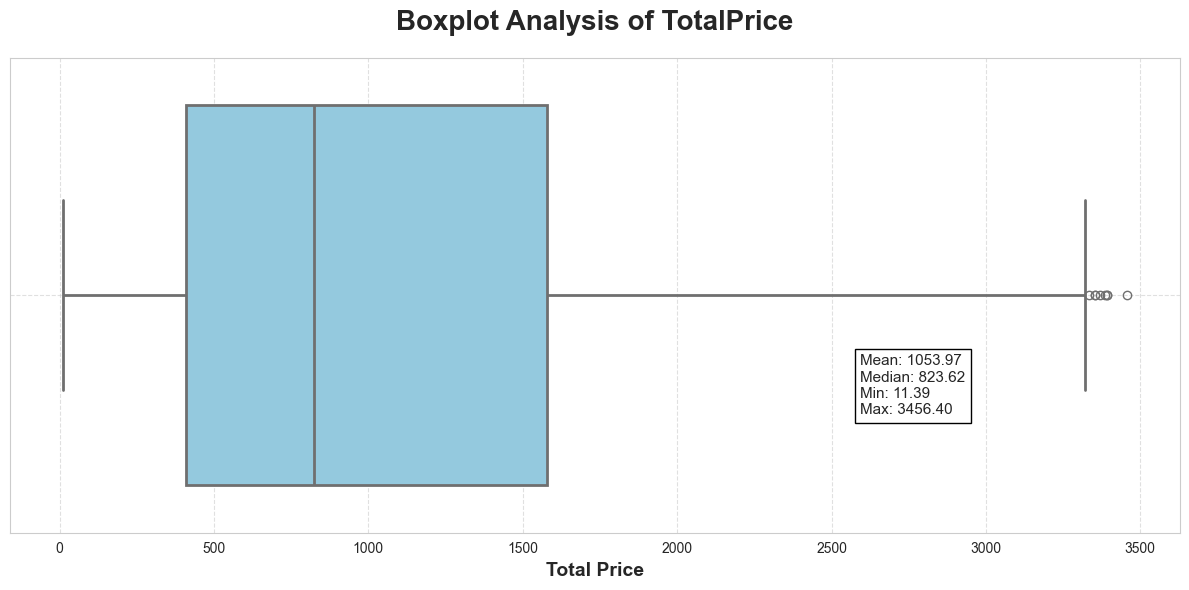

In [24]:

sns.set_style("whitegrid")


plt.figure(figsize=(12,6))


sns.boxplot(
    x=data['TotalPrice'],
    color='skyblue',
    linewidth=2,
    fliersize=6
)

plt.title(
    'Boxplot Analysis of TotalPrice',
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Total Price',
    fontsize=14,
    fontweight='bold'
)


mean_value = data['TotalPrice'].mean()
median_value = data['TotalPrice'].median()
max_value = data['TotalPrice'].max()
min_value = data['TotalPrice'].min()

stats_text = (
    f"Mean: {mean_value:.2f}\n"
    f"Median: {median_value:.2f}\n"
    f"Min: {min_value:.2f}\n"
    f"Max: {max_value:.2f}"
)

plt.text(
    max_value * 0.75,
    0.25,
    stats_text,
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='black')
)


plt.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()


plt.show()

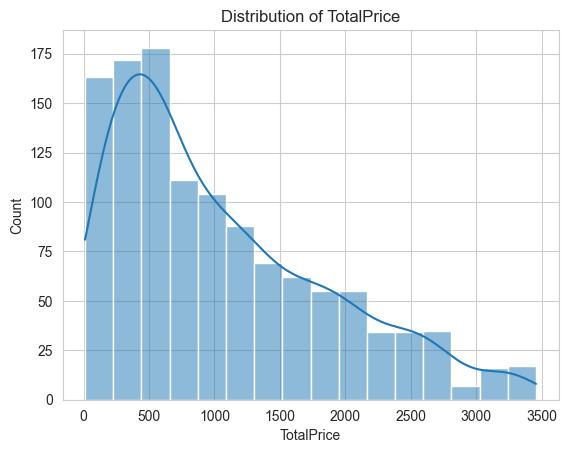

In [25]:
sns.histplot(data['TotalPrice'], kde=True)

plt.title('Distribution of TotalPrice')

plt.show()

In [21]:
data['Date'] = pd.to_datetime(data['Date'])

monthly_sales = data.groupby(
    data['Date'].dt.month
)['TotalPrice'].sum()

print(monthly_sales)

Date
1     124313.23
2     112344.78
3     123840.93
4     109186.05
5     135142.59
6     170616.13
7      85784.64
8      86343.21
9      69321.65
10     89834.82
11     75493.43
12     82540.50
Name: TotalPrice, dtype: float64


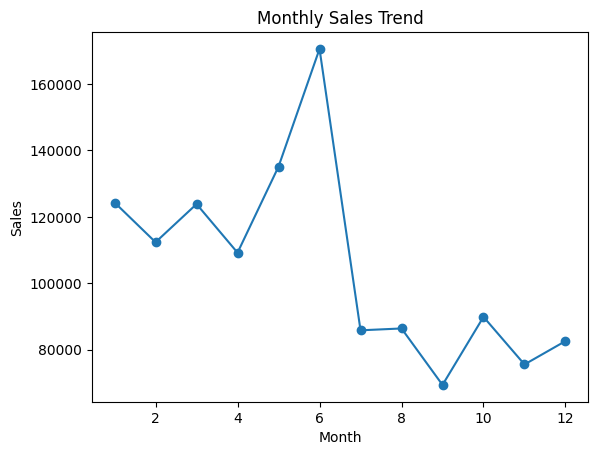

In [22]:
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

In [26]:
data.to_csv('eda_processed_data.csv', index=False)